# OU perturbations on the nominal — mean-reversion sweep, and what the control cloud looks like

Follow-up to `ou_mppi_comparison.ipynb`, which compared four sampling arms at a single
mean-reversion speed θ = 0.3 and found the Gaussian baseline won everywhere. This
notebook narrows to **OU noise on the base nominal only** and sweeps **θ**, then looks
directly at the **cluster of sampled control inputs** that each θ produces.

Three things changed, and the second is a correction to the first study:

1. **Only the nominal-mean OU arm.** The `seqmean` / `prefixmean` variants are dropped.
2. **Two parameterizations, not one.** The first study's `ou_nominal` made the OU
   process revert *to the nominal*. That form is **mean-biased for every θ ≠ 1** — its
   sample cloud sits on an exponential moving average of the nominal, not on the
   nominal. At θ = 0.3 the bias is ≈ 0.92, which is **3× the noise level**. So a θ
   sweep of that form confounds correlation with mean bias. The **additive** form
   (`knots = nominal + zero-mean OU`) is unbiased at every θ and isolates correlation.
   Both are swept here so the confound can be measured rather than assumed.
3. **A measured noise floor.** At θ = 1 both OU forms reduce to the Gaussian baseline
   — additive is *bit-identical*, reverting matches to 4·10⁻¹⁶. Running that arm
   anyway turns it into a control: it measures how much of a cost difference is pure
   chaotic amplification of floating-point roundoff. It turns out to be large, and it
   is the yardstick every other number here is judged against.

θ ∈ {0.1, 0.3, 0.5, 0.8, 1.0, 1.5}, giving lag-1 knot correlation ρ = 1 − θ from
+0.9 (very smooth) through 0 (iid) to −0.5 (zigzag).

In [1]:
import time
from pathlib import Path

import numpy as np

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2
from analytic_mppi.controllers.spline import interpolate

CACHE = Path("runs") / "ou_theta"

T_MAX = 30.0
SEEDS = (0, 1, 2, 3)
THETAS = (0.1, 0.3, 0.5, 0.8, 1.0, 1.5)
ADD_THETAS = tuple(t for t in THETAS if t != 1.0)   # additive theta=1 IS the baseline, bit-identical

REV_ARMS = tuple(f"ou_t{t:g}" for t in THETAS)          # reverts to the nominal (biased)
ADD_ARMS = tuple(f"ouadd_t{t:g}" for t in ADD_THETAS)   # nominal + zero-mean OU (unbiased)
ARMS = ("gaussian",) + REV_ARMS + ADD_ARMS

ENV_LABEL = {"hopper": "hopper", "walker": "walker", "g1_standup": "humanoid standup"}

## Two ways to put OU noise on a nominal

Both build an AR(1) process along the **knot axis** with
σ = `noise_level`·√(θ(2−θ)), which pins the stationary marginal std to `noise_level`
for every θ. So neither changes how *far* samples spread — only how neighbouring knots
co-move (lag-1 correlation ρ = 1 − θ).

**Reverting** (the first study's arm) — the process reverts to the nominal:

$$x_t = x_{t-1} + \theta\,(U_t - x_{t-1}) + \sigma\varepsilon_t$$

Its expectation obeys $m_t = (1-\theta)m_{t-1} + \theta U_t$ — an **EWMA of the
nominal**. With θ = 0.1 that has a ~10-knot time constant but there are only 6 knots,
so the cloud never catches up to the nominal's shape. This is a bias, not noise, and it
grows as θ shrinks.

**Additive** — a zero-mean OU perturbation added to the nominal:

$$z_t = (1-\theta)z_{t-1} + \sigma\varepsilon_t, \qquad \text{knots} = U + z$$

Here $\mathbb{E}[\text{knots}] = U$ **exactly**, for every θ. This is the clean
isolation of temporal correlation, and the more natural reading of "draw the
perturbations from OU noise".

In [2]:
class OUNominalMPPI(MPPIv2):
    """OU along the knot axis, reverting TO the nominal. Mean-biased for theta != 1."""

    def __init__(self, *args, ou_theta: float, **kwargs):
        super().__init__(*args, **kwargs)
        if not 0.0 < ou_theta <= 2.0:
            raise ValueError(f"ou_theta must be in (0, 2], got {ou_theta}")
        self.ou_theta = float(ou_theta)

    def sample_knots(self) -> np.ndarray:
        K, N, nu = self.num_samples, self.num_knots, self.nu
        U, theta = self.mean, self.ou_theta
        sigma = self.noise_level * np.sqrt(theta * (2.0 - theta))
        eps = self.rng.normal(size=(K, N, nu))
        x = np.empty((K, N, nu), dtype=np.float64)
        x[:, 0] = U[0] + self.noise_level * eps[:, 0]
        for t in range(1, N):
            x[:, t] = x[:, t - 1] + theta * (U[t] - x[:, t - 1]) + sigma * eps[:, t]
        return x


class OUAdditiveMPPI(MPPIv2):
    """Zero-mean OU perturbation ADDED to the nominal. Unbiased for every theta."""

    def __init__(self, *args, ou_theta: float, **kwargs):
        super().__init__(*args, **kwargs)
        if not 0.0 < ou_theta <= 2.0:
            raise ValueError(f"ou_theta must be in (0, 2], got {ou_theta}")
        self.ou_theta = float(ou_theta)

    def sample_knots(self) -> np.ndarray:
        K, N, nu = self.num_samples, self.num_knots, self.nu
        theta = self.ou_theta
        sigma = self.noise_level * np.sqrt(theta * (2.0 - theta))
        eps = self.rng.normal(size=(K, N, nu))
        z = np.empty((K, N, nu), dtype=np.float64)
        z[:, 0] = self.noise_level * eps[:, 0]
        for t in range(1, N):
            z[:, t] = (1.0 - theta) * z[:, t - 1] + sigma * eps[:, t]
        return self.mean[None, ...] + z


def arm_theta(arm):
    return None if arm == "gaussian" else float(arm.split("t")[-1])


def make_controller(arm, task, backend, seed, cfg):
    kwargs = dict(task=task, backend=backend, seed=seed,
                  **{k: v for k, v in cfg.items() if k != "task"})
    th = arm_theta(arm)
    if th is None:
        return MPPIv2(**kwargs)
    cls = OUAdditiveMPPI if arm.startswith("ouadd_") else OUNominalMPPI
    return cls(ou_theta=th, **kwargs)

## Verifying both samplers

The table below is the evidence for the bias claim. Both forms hold the marginal std at
`noise_level` and hit the target lag-1 correlation, but their **mean error** — how far
the sample cloud's centre sits from the nominal — behaves completely differently.

In [3]:
_vt = make_task("hopper")
_vb = MujocoBackend(_vt.model_path)
_NL, _N, _K = 0.3, 6, 20_000
_U = np.random.default_rng(3).normal(scale=0.4, size=(_N, _vt.nu))
_kw = lambda: dict(task=_vt, backend=_vb, num_samples=_K, noise_level=_NL, temperature=0.05,
                   num_knots=_N, plan_horizon=0.8, spline_type="cubic", iterations=1, seed=5)


def _draw(cls, th):
    c = cls(ou_theta=th, **_kw()); c.mean = _U.copy(); return c.sample_knots()


def _lag1(x):
    a, b = x[:, :-1] - x[:, :-1].mean(0), x[:, 1:] - x[:, 1:].mean(0)
    return float(np.mean((a * b).mean(0) / (a.std(0) * b.std(0))))


print(f"{_K:,} draws | num_knots={_N} | noise_level={_NL}\n")
print(f"{'theta':>6s} {'rho target':>11s} | {'ADDITIVE  std':>14s} {'rho':>7s} {'mean err':>9s}"
      f" | {'REVERTING  std':>15s} {'rho':>7s} {'mean err':>9s}")
print("-" * 92)
_ok = True
for _th in THETAS:
    _xa, _xr = _draw(OUAdditiveMPPI, _th), _draw(OUNominalMPPI, _th)
    _ea, _er = np.abs(_xa.mean(0) - _U).max(), np.abs(_xr.mean(0) - _U).max()
    print(f"{_th:6.1f} {1-_th:11.2f} | {_xa.std(0).mean():14.4f} {_lag1(_xa):7.3f} {_ea:9.4f}"
          f" | {_xr.std(0).mean():15.4f} {_lag1(_xr):7.3f} {_er:9.4f}")
    # additive must be unbiased and correctly correlated at every theta
    _ok &= _ea < 0.02 and abs(_xa.std(0).mean() - _NL) < 0.01 and abs(_lag1(_xa) - (1 - _th)) < 0.03

# theta = 1 collapses onto the Gaussian baseline
_g = MPPIv2(**_kw()); _g.mean = _U.copy()
_xg = _g.sample_knots()
_d_add = np.abs(_xg - _draw(OUAdditiveMPPI, 1.0)).max()
_d_rev = np.abs(_xg - _draw(OUNominalMPPI, 1.0)).max()
print(f"\ntheta=1 vs Gaussian baseline:  additive max|diff| = {_d_add:.1e} (bit-identical)"
      f"   reverting max|diff| = {_d_rev:.1e} (roundoff)")
_ok &= _d_add == 0.0 and _d_rev < 1e-12

assert _ok, "sampler verification FAILED"
print("\nBoth samplers verified. Note the REVERTING mean error: it is not noise, it is bias,")
print(f"and at theta=0.3 it is {np.abs(_draw(OUNominalMPPI, 0.3).mean(0) - _U).max() / _NL:.1f}x the noise level.")

20,000 draws | num_knots=6 | noise_level=0.3

 theta  rho target |  ADDITIVE  std     rho  mean err |  REVERTING  std     rho  mean err
--------------------------------------------------------------------------------------------
   0.1        0.90 |         0.2990   0.899    0.0045 |          0.2990   0.899    1.3696
   0.3        0.70 |         0.2993   0.699    0.0045 |          0.2993   0.699    0.9174
   0.5        0.50 |         0.2995   0.498    0.0045 |          0.2995   0.498    0.7925
   0.8        0.20 |         0.2997   0.198    0.0045 |          0.2997   0.198    0.3948
   1.0        0.00 |         0.2998  -0.001    0.0046 |          0.2998  -0.001    0.0046
   1.5       -0.50 |         0.2998  -0.500    0.0063 |          0.2998  -0.500    1.2594

theta=1 vs Gaussian baseline:  additive max|diff| = 0.0e+00 (bit-identical)   reverting max|diff| = 4.4e-16 (roundoff)

Both samplers verified. Note the REVERTING mean error: it is not noise, it is bias,
and at theta=0.3 it is 3.1

## The cluster of sampled control inputs

This is the direct answer to "what does the control cloud look like". For a fixed
nominal (black), 60 sampled control sequences interpolated through the cubic spline onto
the plan horizon, plus the sample cluster in the (knot 0, knot 1) plane with its 1σ and
2σ covariance ellipses.

Read the rows against each other:

* **Reverting (row 1)** — at θ = 0.1 the cloud is nearly flat and does not follow the
  nominal's swing at all; at θ = 1.5 it wildly overshoots it. Only at θ = 1 does it sit
  on the nominal. That is the bias, drawn.
* **Additive (row 2)** — the cloud straddles the nominal at every θ. Low θ gives smooth,
  coherent offsets of the whole sequence; θ = 1 gives independent per-knot jitter;
  θ = 1.5 gives a zigzag that fights itself knot to knot.
* **The cluster (row 3)** — tilts from a +45° cigar at θ = 0.1 (knots move together),
  through a circle at θ = 1 (independent), to a −45° cigar at θ = 1.5 (knots move
  oppositely). The `+` marks the nominal; the additive cloud is centred on it throughout.

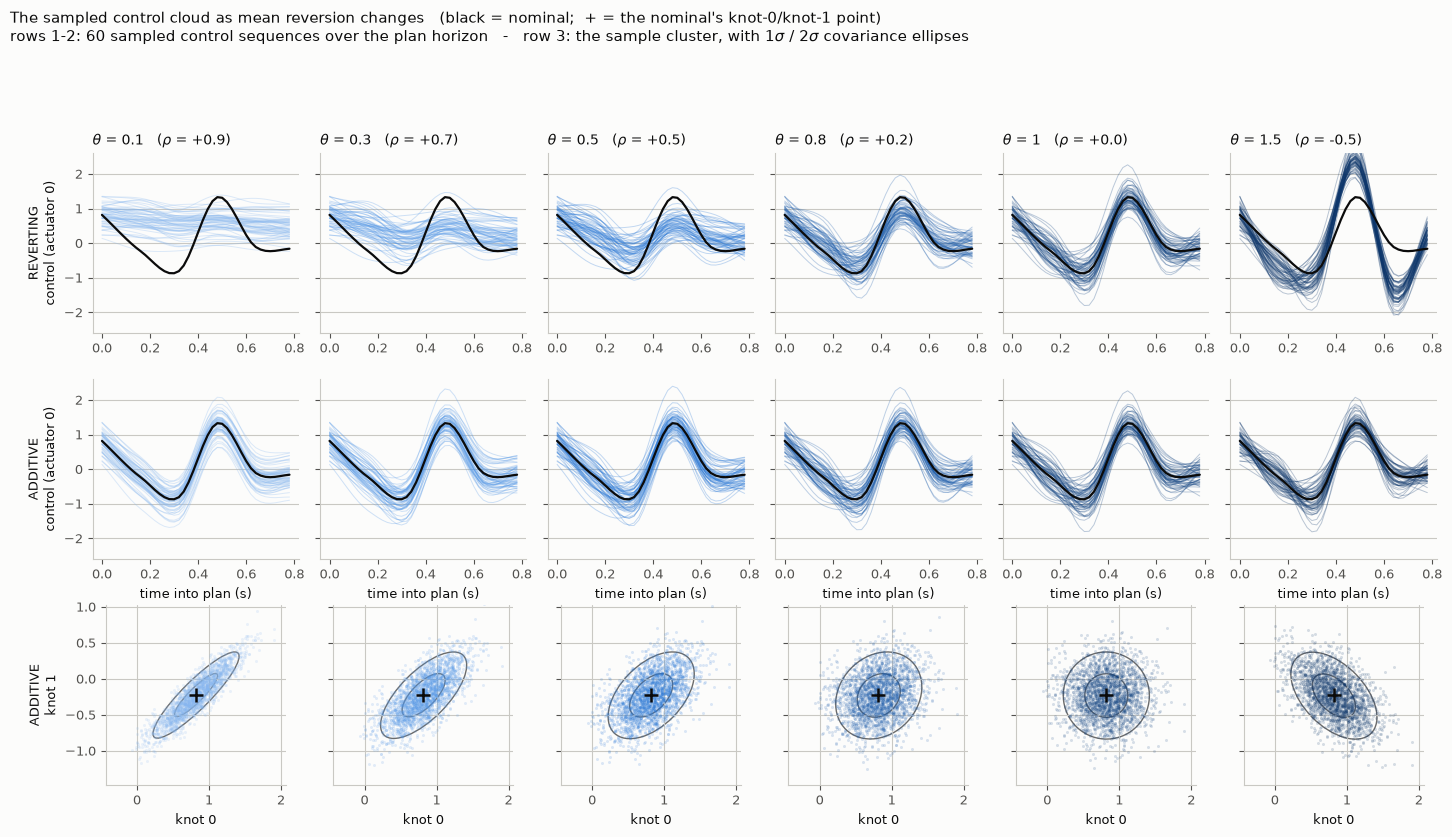

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#c9c8c3"
# theta is an ORDERED variable -> ordinal ramp (single hue, light->dark), not categorical hues.
# Steps 250..700 of the reference blue ramp; the lightest clears the 2:1 ordinal floor.
THETA_COLOR = dict(zip(THETAS, ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]))
FORM_COLOR = {"reverting": "#2a78d6", "additive": "#eb6834"}   # two categorical contexts
FLOOR = "#c9c8c3"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": SECOND, "ytick.color": SECOND,
    "axes.grid": True, "grid.color": MUTED, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "legend.frameon": False,
})

_ACT = 0
_c0 = MPPIv2(**_kw()); _c0.mean = _U.copy()
_nom_u = interpolate(_U[None], _c0.tk, _c0.t_eval, "cubic")[0][:, _ACT]

fig, axes = plt.subplots(3, len(THETAS), figsize=(14.5, 8.2))
for j, th in enumerate(THETAS):
    col = THETA_COLOR[th]
    xr, xa = _draw(OUNominalMPPI, th), _draw(OUAdditiveMPPI, th)

    for row, x in ((0, xr), (1, xa)):
        ax = axes[row, j]
        for r in interpolate(x[:60], _c0.tk, _c0.t_eval, "cubic")[:, :, _ACT]:
            ax.plot(_c0.t_eval, r, color=col, lw=0.7, alpha=0.28)
        ax.plot(_c0.t_eval, _nom_u, color=INK, lw=1.6)
        ax.set_ylim(-2.6, 2.6)
        ax.grid(axis="x", visible=False)
        if j:
            ax.set_yticklabels([])
        if row == 0:
            ax.set_title(f"$\\theta$ = {th:g}   ($\\rho$ = {1-th:+.1f})", color=INK, loc="left", pad=6)
        else:
            ax.set_xlabel("time into plan (s)")

    ax = axes[2, j]
    k0, k1 = xa[:, 0, _ACT], xa[:, 1, _ACT]
    ax.plot(k0[:2500], k1[:2500], ls="none", marker="o", ms=2.2, color=col, alpha=0.16, mec="none")
    S = np.cov(k0, k1)
    lam, vec = np.linalg.eigh(S)
    ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
    for k in (1, 2):
        ax.add_patch(mpl.patches.Ellipse((k0.mean(), k1.mean()),
                                         2*k*np.sqrt(lam[-1]), 2*k*np.sqrt(lam[0]), angle=ang,
                                         fill=False, color=INK, lw=1.0, alpha=0.6))
    ax.plot([_U[0, _ACT]], [_U[1, _ACT]], marker="+", ms=10, color=INK, mew=1.8)
    ax.set_xlim(_U[0, _ACT] - 1.25, _U[0, _ACT] + 1.25)
    ax.set_ylim(_U[1, _ACT] - 1.25, _U[1, _ACT] + 1.25)
    ax.set_aspect("equal")
    ax.set_xlabel("knot 0")
    if j:
        ax.set_yticklabels([])

axes[0, 0].set_ylabel("REVERTING\ncontrol (actuator 0)")
axes[1, 0].set_ylabel("ADDITIVE\ncontrol (actuator 0)")
axes[2, 0].set_ylabel("ADDITIVE\nknot 1")
fig.suptitle("The sampled control cloud as mean reversion changes   (black = nominal;  + = the nominal's knot-0/knot-1 point)\n"
             "rows 1-2: 60 sampled control sequences over the plan horizon   -   row 3: the sample cluster, with 1$\\sigma$ / 2$\\sigma$ covariance ellipses",
             color=INK, fontsize=11, x=0.006, ha="left", y=0.998)
fig.tight_layout(rect=[0, 0, 1, 0.925])
plt.show()

## How many directions does the cloud actually explore?

Correlating the knots shrinks the cloud onto a lower-dimensional subspace. The
**participation ratio** of the knot-axis covariance,

$$\mathrm{PR} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2},$$

counts the effective number of independent knot directions — 1 if all knots move as a
single block, 6 (`num_knots`) if they are independent. For an AR(1) cloud it has a
closed form, $\mathrm{PR} = n^2 / \sum_{ij}\rho^{2|i-j|}$, which the empirical estimate
should reproduce exactly.

Note what PR does at θ = 1.5: **anti**-correlation collapses dimensionality just as
positive correlation does. PR is a function of |ρ|, so θ = 1.5 (ρ = −0.5) and θ = 0.5
(ρ = +0.5) have essentially the same PR. That makes a sharp prediction — *if*
dimensionality is what drives performance, those two θ should behave alike. The sweep
below tests it.

In [5]:
def participation_ratio(x):
    """Effective number of independent knot directions, averaged over actuators."""
    prs = []
    for j in range(x.shape[2]):
        lam = np.linalg.eigvalsh(np.cov(x[:, :, j].T))
        prs.append(lam.sum() ** 2 / (lam ** 2).sum())
    return float(np.mean(prs))


def pr_analytic(rho, n=6):
    i = np.arange(n)
    return n ** 2 / ((rho ** np.abs(i[:, None] - i[None, :])) ** 2).sum()


rows = []
for th in THETAS:
    xa = _draw(OUAdditiveMPPI, th)
    rows.append((th, 1 - th, participation_ratio(xa), pr_analytic(1 - th),
                 np.abs(_draw(OUNominalMPPI, th).mean(0) - _U).max() / _NL))

print(f"{'theta':>6s} {'rho':>7s} {'PR empirical':>13s} {'PR analytic':>12s}   {'reverting bias':>15s}")
print(f"{'':6s} {'':7s} {'(max 6)':>13s} {'':12s}   {'(x noise level)':>15s}")
print("-" * 62)
for th, rho, pe, pa, bias in rows:
    print(f"{th:6.1f} {rho:7.2f} {pe:13.2f} {pa:12.2f}   {bias:15.1f}")

_p = {th: pe for th, _, pe, _, _ in rows}
print(f"\nprediction to test: theta=0.5 (PR {_p[0.5]:.2f}) and theta=1.5 (PR {_p[1.5]:.2f}) "
      f"explore the same number of directions.")

 theta     rho  PR empirical  PR analytic    reverting bias
                     (max 6)                (x noise level)
--------------------------------------------------------------
   0.1    0.90          1.44         1.44               4.6
   0.3    0.70          2.61         2.61               3.1
   0.5    0.50          3.96         3.95               2.6
   0.8    0.20          5.62         5.61               1.3
   1.0    0.00          6.00         6.00               0.0
   1.5   -0.50          3.95         3.95               4.2

prediction to test: theta=0.5 (PR 3.96) and theta=1.5 (PR 3.95) explore the same number of directions.


## Environments and driver

Identical to the first study — same tasks, same hyperparameters, same scripted G1
collapse — with one addition: the **applied control** at every step is now recorded, so
the realized control signal can be clustered too.

In [6]:
ENVS = {
    "hopper": dict(task="hopper", num_samples=256, noise_level=0.3, temperature=0.05,
                   num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
    "walker": dict(task="walker", num_samples=256, noise_level=0.3, temperature=0.05,
                   num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
    "g1_standup": dict(task="g1_standup", num_samples=256, noise_level=0.15, temperature=0.05,
                       num_knots=6, plan_horizon=0.8, spline_type="cubic", iterations=2),
}


def g1_collapse(backend, fold_t=3.0, settle_t=2.0):
    fold = np.zeros(backend.nu)
    fold[[0, 6]] = -1.8
    fold[[3, 9]] = 2.6
    fold[[4, 10]] = -0.6
    n_fold, n_settle = round(fold_t / backend.dt), round(settle_t / backend.dt)
    for step in range(n_fold + n_settle):
        backend.step(fold if step < n_fold else np.zeros(backend.nu))
    return backend.get_state().copy()


def initial_state(env_name, backend):
    return g1_collapse(backend) if env_name == "g1_standup" else backend.get_state().copy()


def run_episode(env_name, arm, seed, *, t_max=T_MAX, cache_dir=CACHE, use_cache=True, verbose=True):
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{env_name}_{arm}_seed{seed}.npz"
    if use_cache and path.exists():
        with np.load(path) as z:
            return {k: z[k] for k in z.files}

    cfg = ENVS[env_name]
    task = make_task(cfg["task"])
    backend = MujocoBackend(task.model_path)
    state0 = initial_state(env_name, backend)
    ctrl = make_controller(arm, task, backend, seed, cfg)
    backend.set_state(state0)
    ctrl.reset()

    cost_terms, plan_times, torso_z, controls = [], [], [], []
    t_wall = time.perf_counter()
    for _ in range(round(t_max / backend.dt)):
        t0 = time.perf_counter()
        u = ctrl.act(backend.get_state())
        plan_times.append(time.perf_counter() - t0)
        backend.step(u)
        controls.append(np.asarray(u).copy())
        cost_terms.append(task.running_cost_terms(
            np.asarray(backend.data.qpos), np.asarray(backend.data.qvel),
            np.asarray(backend.data.sensordata), np.asarray(u)))
        torso_z.append(float(task._torso_height(np.asarray(backend.data.sensordata))))
    elapsed = time.perf_counter() - t_wall

    cost_terms = np.asarray(cost_terms)
    out = dict(cost=cost_terms.sum(axis=-1), cost_terms=cost_terms,
               term_names=np.asarray(task.cost_term_names), torso_z=np.asarray(torso_z),
               controls=np.asarray(controls), plan_times=np.asarray(plan_times),
               dt=np.asarray(backend.dt), wall_seconds=np.asarray(elapsed))
    np.savez_compressed(path, **out)
    if verbose:
        print(f"  {env_name:11s} {arm:12s} seed {seed}  mean cost {out['cost'].mean():9.3f}  "
              f"{elapsed:5.1f}s", flush=True)
    return out

## Run the sweeps

144 episodes: 3 environments × 4 seeds × (1 Gaussian + 6 reverting θ + 5 additive θ).
Additive θ = 1 is omitted — it is bit-identical to the Gaussian baseline by
construction, as asserted above, so simulating it would reproduce those runs exactly.

From cold this is ~85 minutes; from the `runs/ou_theta/` cache it returns immediately.

In [7]:
results = {}
t0 = time.perf_counter()
for env_name in ENVS:
    for arm in ARMS:
        for seed in SEEDS:
            results[(env_name, arm, seed)] = run_episode(env_name, arm, seed, verbose=False)
print(f"{len(results)} episodes ready in {time.perf_counter() - t0:.1f}s (cached in {CACHE})")

DT = {e: float(results[(e, "gaussian", 0)]["dt"]) for e in ENVS}
mean_cost = {(e, a): np.array([results[(e, a, s)]["cost"].mean() for s in SEEDS])
             for e in ENVS for a in ARMS}

144 episodes ready in 0.2s (cached in runs/ou_theta)


## First: how big is the noise floor?

`gaussian` and reverting `θ = 1` are **the same algorithm**, differing only by ~4·10⁻¹⁶
of floating-point roundoff in the knot values. Any spread between them is pure chaotic
amplification over a 30 s contact-rich episode — not a property of the sampler.

That makes them 8 runs of one algorithm, and their spread is the threshold below which
*no* difference in this notebook (or the previous one) means anything.

In [8]:
floor = {}
print(f"{'env':18s} {'gaussian mean':>14s} {'theta=1 mean':>13s} {'gap':>7s}   "
      f"{'pooled 8-run range':>22s}   {'as +/- of mean':>15s}")
print("-" * 100)
for e in ENVS:
    g, t1 = mean_cost[(e, "gaussian")], mean_cost[(e, "ou_t1")]
    pool = np.concatenate([g, t1])
    floor[e] = (pool.min(), pool.max(), pool.mean())
    print(f"{ENV_LABEL[e]:18s} {g.mean():14.3f} {t1.mean():13.3f} "
          f"{abs(g.mean()-t1.mean())/g.mean()*100:6.1f}%   "
          f"[{pool.min():8.3f}, {pool.max():8.3f}]   "
          f"-{(1-pool.min()/pool.mean())*100:4.0f}% / +{(pool.max()/pool.mean()-1)*100:.0f}%")

print("\nworst per-seed pair (identical algorithm, identical seed, 4e-16 apart in the knots):")
for e in ENVS:
    g, t1 = mean_cost[(e, "gaussian")], mean_cost[(e, "ou_t1")]
    rel = np.abs(g - t1) / g
    i = int(rel.argmax())
    print(f"  {ENV_LABEL[e]:18s} seed {SEEDS[i]}: {g[i]:.3f} vs {t1[i]:.3f}  ->  {rel[i]*100:.1f}% apart")

env                 gaussian mean  theta=1 mean     gap       pooled 8-run range    as +/- of mean
----------------------------------------------------------------------------------------------------
hopper                      1.156         1.086    6.0%   [   0.937,    1.226]   -  16% / +9%
walker                      0.200         0.200    0.2%   [   0.177,    0.222]   -  11% / +11%
humanoid standup           10.321        10.363    0.4%   [  10.292,   10.488]   -   0% / +1%

worst per-seed pair (identical algorithm, identical seed, 4e-16 apart in the knots):
  hopper             seed 3: 1.125 vs 0.937  ->  16.7% apart
  walker             seed 1: 0.221 vs 0.177  ->  19.9% apart
  humanoid standup   seed 0: 10.315 vs 10.488  ->  1.7% apart


## Cost against θ

Episode-mean cost indexed to the Gaussian baseline, for both parameterizations, with
the measured noise floor as a gray band. **A point inside the band is not
distinguishable from the baseline** — it is what running the same algorithm twice
produces. θ = 1 is marked because both forms provably collapse onto the baseline there.

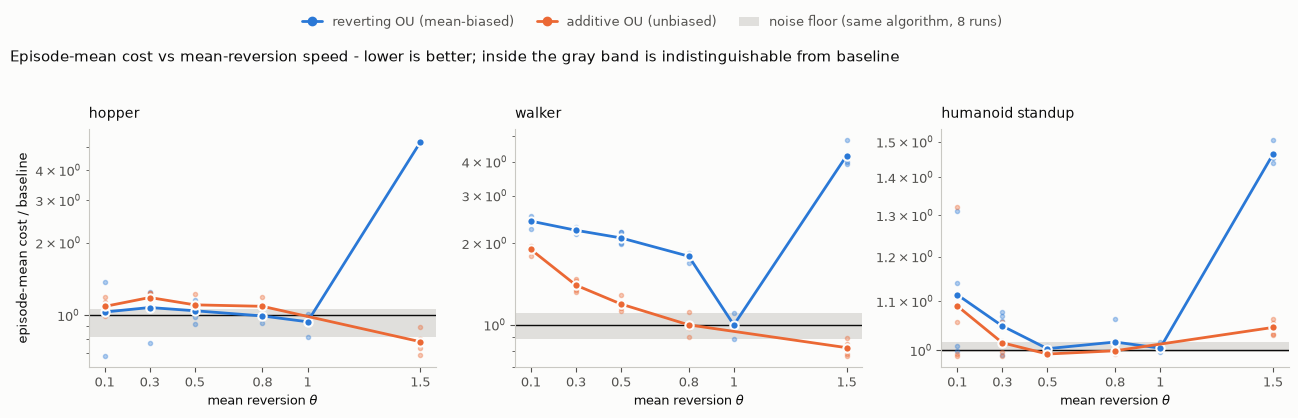

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, env_name in zip(axes, ENVS):
    b = mean_cost[(env_name, "gaussian")].mean()
    lo, hi, _ = floor[env_name]
    ax.axhspan(lo / b, hi / b, color=FLOOR, alpha=0.55, lw=0, zorder=1)
    ax.axhline(1.0, color=INK, lw=1, zorder=2)

    for form, arms, ths in (("reverting", REV_ARMS, THETAS), ("additive", ADD_ARMS, ADD_THETAS)):
        m = np.array([mean_cost[(env_name, a)].mean() / b for a in arms])
        seeds_rel = [mean_cost[(env_name, a)] / b for a in arms]
        ax.plot(ths, m, color=FORM_COLOR[form], marker="o", ms=6, mec=SURFACE, mew=1.5, zorder=4)
        for th, sr in zip(ths, seeds_rel):
            ax.plot(np.full(len(sr), th), sr, ls="none", marker="o", ms=3,
                    color=FORM_COLOR[form], alpha=0.35, zorder=3)

    ax.set_yscale("log")
    ax.set_xlabel(r"mean reversion $\theta$")
    ax.set_title(ENV_LABEL[env_name], color=INK, loc="left", pad=8)
    ax.grid(axis="x", visible=False)
    ax.set_xticks(list(THETAS))
    ax.set_xticklabels([f"{t:g}" for t in THETAS])

axes[0].set_ylabel("episode-mean cost / baseline")
handles = [mpl.lines.Line2D([], [], color=FORM_COLOR[f], lw=2, marker="o", ms=6, label=l)
           for f, l in (("reverting", "reverting OU (mean-biased)"),
                        ("additive", "additive OU (unbiased)"))]
handles.append(mpl.patches.Patch(facecolor=FLOOR, alpha=0.55, label="noise floor (same algorithm, 8 runs)"))
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=3,
           fontsize=9, labelcolor=SECOND, handlelength=1.6, columnspacing=1.8)
fig.suptitle("Episode-mean cost vs mean-reversion speed - lower is better; inside the gray band is indistinguishable from baseline",
             color=INK, fontsize=11, x=0.006, ha="left", y=0.885)
fig.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

## The cluster of the *executed* control inputs

Everything above is the sampling distribution. This is what actually came out of the
controller and went into the robot — the closed-loop control signal over the full 30 s.

Left: the executed-control cluster in the $(u_t, u_{t+1})$ plane for one actuator, which
is the realized analogue of the sampled-knot cluster. Right: two summary statistics
against θ — the lag-1 autocorrelation of the executed signal, and its mean absolute
step $\langle|u_{t+1}-u_t|\rangle$, i.e. how much the commanded control jitters.

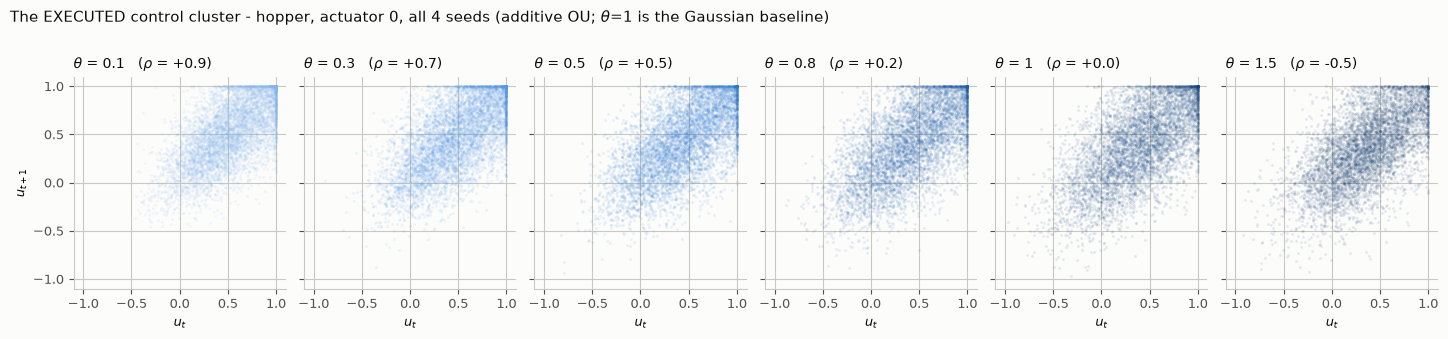

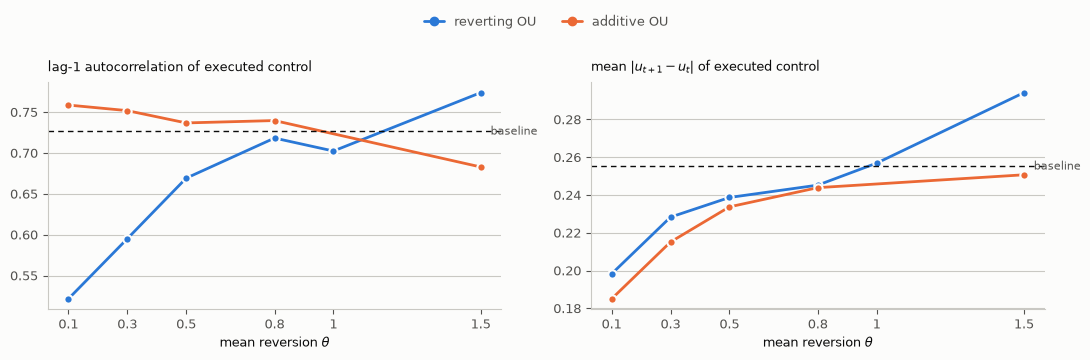

hopper - executed control statistics
  arm               lag-1 autocorr   mean |du|
  gaussian                  0.7264      0.2551
  ou_t0.1                   0.5215      0.1982
  ou_t0.3                   0.5950      0.2283
  ou_t0.5                   0.6692      0.2387
  ou_t0.8                   0.7183      0.2452
  ou_t1                     0.7024      0.2569
  ou_t1.5                   0.7739      0.2942
  ouadd_t0.1                0.7587      0.1850
  ouadd_t0.3                0.7519      0.2151
  ouadd_t0.5                0.7368      0.2337
  ouadd_t0.8                0.7397      0.2439
  ouadd_t1.5                0.6829      0.2507


In [10]:
def applied(env_name, arm, seed):
    return results[(env_name, arm, seed)]["controls"]


def applied_stats(env_name, arm):
    """(lag-1 autocorr, mean |du|) of the executed control, averaged over seeds+actuators."""
    ac, tv = [], []
    for s in SEEDS:
        u = applied(env_name, arm, s)
        a, b = u[:-1] - u[:-1].mean(0), u[1:] - u[1:].mean(0)
        sd = a.std(0) * b.std(0)
        ok = sd > 1e-12
        ac.append(np.mean(((a * b).mean(0)[ok]) / sd[ok]) if ok.any() else np.nan)
        tv.append(np.mean(np.abs(np.diff(u, axis=0))))
    return float(np.nanmean(ac)), float(np.mean(tv))


ENV_SHOW, ACT_SHOW = "hopper", 0
# additive form throughout; theta=1 has no additive arm because it IS the baseline
SHOW_ARMS = [(t, f"ouadd_t{t:g}" if t != 1.0 else "gaussian") for t in THETAS]

# --- executed-control cluster, one panel per theta (mirrors the sampled-cluster row) ---
fig, axes = plt.subplots(1, len(SHOW_ARMS), figsize=(14.5, 2.9))
for ax, (th, arm) in zip(axes, SHOW_ARMS):
    u = np.concatenate([applied(ENV_SHOW, arm, s)[:, ACT_SHOW] for s in SEEDS])
    ax.plot(u[:-1], u[1:], ls="none", marker="o", ms=2.0, color=THETA_COLOR[th],
            alpha=0.10, mec="none")
    ax.set_title(f"$\\theta$ = {th:g}   ($\\rho$ = {1-th:+.1f})", color=INK, loc="left", pad=6)
    ax.set_xlabel("$u_t$")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)   # actuator range, shared across panels
    ax.set_aspect("equal")
    if ax is axes[0]:
        ax.set_ylabel("$u_{t+1}$")
    else:
        ax.set_yticklabels([])
fig.suptitle(f"The EXECUTED control cluster - {ENV_LABEL[ENV_SHOW]}, actuator {ACT_SHOW}, all 4 seeds "
             f"(additive OU; $\\theta$=1 is the Gaussian baseline)",
             color=INK, fontsize=11, x=0.006, ha="left", y=1.06)
fig.tight_layout()
plt.show()

# --- summary statistics of the executed signal ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (idx, lab) in zip(axes, ((0, "lag-1 autocorrelation of executed control"),
                                 (1, r"mean $|u_{t+1}-u_t|$ of executed control"))):
    for form, arms, ths in (("reverting", REV_ARMS, THETAS), ("additive", ADD_ARMS, ADD_THETAS)):
        ax.plot(ths, [applied_stats(ENV_SHOW, a)[idx] for a in arms],
                color=FORM_COLOR[form], marker="o", ms=6, mec=SURFACE, mew=1.5)
    gv = applied_stats(ENV_SHOW, "gaussian")[idx]
    ax.axhline(gv, color=INK, lw=1, ls=(0, (4, 3)))
    ax.text(1.52, gv, " baseline", color=SECOND, fontsize=8, va="center", ha="left")
    ax.set_xlabel(r"mean reversion $\theta$")
    ax.set_title(lab, color=INK, loc="left", pad=8, fontsize=9)
    ax.grid(axis="x", visible=False)
    ax.set_xticks(list(THETAS)); ax.set_xticklabels([f"{t:g}" for t in THETAS])

handles = [mpl.lines.Line2D([], [], color=FORM_COLOR[f], lw=2, marker="o", ms=6, label=l)
           for f, l in (("reverting", "reverting OU"), ("additive", "additive OU"))]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2,
           fontsize=9, labelcolor=SECOND, handlelength=1.6)
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

print(f"{ENV_LABEL[ENV_SHOW]} - executed control statistics")
print(f"  {'arm':16s} {'lag-1 autocorr':>15s} {'mean |du|':>11s}")
for a in ("gaussian",) + REV_ARMS + ADD_ARMS:
    ac, tv = applied_stats(ENV_SHOW, a)
    print(f"  {a:16s} {ac:15.4f} {tv:11.4f}")

## The numbers

In [11]:
STAND_Z = 0.85
for env_name in ENVS:
    b = mean_cost[(env_name, "gaussian")].mean()
    lo, hi, _ = floor[env_name]
    is_g1 = env_name == "g1_standup"
    print(f"\n{ENV_LABEL[env_name]}   baseline {b:,.3f}   noise floor [{lo/b:.2f}, {hi/b:.2f}] x baseline")
    head = f"  {'arm':16s} {'mean cost':>17s} {'vs base':>8s} {'verdict':>16s}"
    print(head + ("   stood" if is_g1 else ""))
    print("  " + "-" * (len(head) + (10 if is_g1 else 0)))
    for a in ("gaussian",) + REV_ARMS + ADD_ARMS:
        mc = mean_cost[(env_name, a)]
        inside = lo <= mc.mean() <= hi
        verdict = "= baseline" if inside else ("WORSE" if mc.mean() > hi else "better")
        row = (f"  {a:16s} {mc.mean():10,.3f} +/-{mc.std():5.3f} {mc.mean()/b:8.2f} {verdict:>16s}")
        if is_g1:
            n_ok = sum(1 for s in SEEDS if (results[(env_name, a, s)]["torso_z"] >= STAND_Z).any())
            row += f"   {n_ok}/4"
        print(row)


hopper   baseline 1.156   noise floor [0.81, 1.06] x baseline
  arm                      mean cost  vs base          verdict
  --------------------------------------------------------------
  gaussian              1.156 +/-0.045     1.00       = baseline
  ou_t0.1               1.192 +/-0.284     1.03       = baseline
  ou_t0.3               1.244 +/-0.219     1.08            WORSE
  ou_t0.5               1.206 +/-0.112     1.04       = baseline
  ou_t0.8               1.148 +/-0.058     0.99       = baseline
  ou_t1                 1.086 +/-0.089     0.94       = baseline
  ou_t1.5               6.032 +/-0.091     5.22            WORSE
  ouadd_t0.1            1.257 +/-0.092     1.09            WORSE
  ouadd_t0.3            1.369 +/-0.078     1.18            WORSE
  ouadd_t0.5            1.276 +/-0.088     1.10            WORSE
  ouadd_t0.8            1.259 +/-0.088     1.09            WORSE
  ouadd_t1.5            0.898 +/-0.090     0.78           better

walker   baseline 0.200   no

## Conclusion

### 1. The noise floor is the first thing to establish, and it is large

`gaussian` and reverting `θ = 1` are the same algorithm to 4·10⁻¹⁶. Run with the *same
seed*, they still diverge by up to **17% (hopper) and 20% (walker)** in 30 s episode
cost — pure chaotic amplification of roundoff in contact-rich dynamics. The humanoid's
floor is only **2%**, because standup is strongly attracting: once up, it stays up, and
perturbations decay instead of growing.

Any claim smaller than those margins is unsupportable. This retroactively bounds the
first study too: its hopper differences (+8%, +12%, +19%) sit at or inside hopper's
floor and should not have been read as effects. Its walker and humanoid results, which
were much larger, survive.

### 2. The first study's OU arm was mean-biased, and that was most of what it measured

Making the OU process revert *to* the nominal gives it propagated mean
$m_t = (1-\theta)m_{t-1} + \theta U_t$ — an EWMA of the nominal, not the nominal. At
θ = 0.3 the sample cloud sits **3.1× the noise level** away from the nominal. The
cluster figure shows it directly: at θ = 0.1 the sampled sequences are nearly flat while
the nominal swings through its full range.

Correcting it changes conclusions, in both directions:

| | reverting (biased) | additive (unbiased) |
|---|---|---|
| hopper θ=1.5 | 5.22× — catastrophic | **0.78× — best arm** |
| walker θ=1.5 | 4.21× — catastrophic | **0.82× — best arm** |
| walker θ=0.8 | 1.79× worse | 1.00× — indistinguishable |

The catastrophic anti-correlation result was **entirely the mean bias**. Every
"correlation hurts" number from the reverting form is contaminated by it.

### 3. Correlation *sign* is what matters — and effective dimensionality does not explain it

The unbiased sweep on walker is cleanly monotone in θ across the whole range:

| θ | 0.1 | 0.3 | 0.5 | 0.8 | 1.0 | 1.5 |
|---|---|---|---|---|---|---|
| ρ | +0.9 | +0.7 | +0.5 | +0.2 | 0.0 | −0.5 |
| cost / baseline | 1.90 | 1.40 | 1.19 | 1.00 | 1.00 | **0.82** |

Positive knot correlation (smooth, coherent perturbations) is consistently bad; the
Gaussian baseline is the break-even point; **anti-correlation is better than both** on
locomotion.

This **falsifies the participation-ratio hypothesis** offered earlier. θ = 0.5 and
θ = 1.5 explore essentially the same number of independent knot directions (PR 3.96 vs
3.95) — PR depends on |ρ| — yet they land on opposite sides of the baseline (1.19× vs
0.82×). Dimensionality is not the mechanism.

A plausible replacement, consistent with the split between task types: anti-correlated
knots produce a rapidly alternating control signal. With 6 knots over a 0.8 s horizon,
knot-to-knot alternation is a ~3 Hz oscillation, which is in the band a hopping or
walking gait actually uses. The humanoid standup is a single smooth monotone rise, has
no such band, and is the one environment where anti-correlation does **not** help
(1.05×, mildly worse). This is a hypothesis suggested by the data, not something these
runs isolate — it predicts the optimal θ should track gait frequency, which a horizon
or knot-count sweep could test.

### 4. Most of the sampling correlation never reaches the robot

The executed-control statistics explain why the positive-θ effects are as small as they
are. Sampled knot correlation swings across a range of **1.4** (ρ = +0.9 → −0.5), but
the lag-1 autocorrelation of the control actually applied moves only **0.76 → 0.68** —
a range of 0.08, and it stays high throughout. MPPI's softmax average over 256 samples,
followed by the warm-start shift, washes out most of the structure that was so carefully
built into the sample cloud.

So the sampler's correlation is largely a *search* property, not a property of the
emitted signal: it changes which trajectories get explored, not how smooth the command
is. That reframes the whole exercise — OU noise is not a way to get smoother controls
here, because the executed control was already smooth (autocorrelation 0.73) under plain
Gaussian sampling.

### 5. What to actually do

Nothing here justifies changing `MPPIv2`'s default. Smooth OU noise — the intuitive
choice, and the DDPG-style default — is the *worst* option tested and is never better
than the Gaussian baseline in any environment at any θ.

The anti-correlated result is the interesting one, but it should be treated as a lead,
not a recommendation: −22% (hopper) and −18% (walker) clear their noise floors of 19%
and 11%, but not by a wide margin on 4 seeds, and it costs 5% on the humanoid. Worth a
confirmation run at more seeds and a couple of θ > 1 values before anyone relies on it.

### 6. Caveats

Hyperparameters are the Gaussian-tuned values throughout, which is the baseline's home
turf; a fair best-case for any OU arm would retune `noise_level` and `temperature` per
θ. Four seeds is thin for effects near the noise floor — that floor is precisely why.
θ > 1 was sampled at a single point (1.5); the region between 1.0 and 2.0 is
unexplored and is where the only positive result lives.